In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Auto-scan Kaggle input directories for your real CSV file
search_path = "../input/**/tesla_deliveries_dataset_2015_2025.csv"
found_files = glob.glob(search_path, recursive=True)

if found_files:
    csv_path = found_files[0]
    print(f"Success! Found real dataset at: '{csv_path}'")
    df = pd.read_csv(csv_path)
elif os.path.exists("tesla_deliveries_dataset_2015_2025.csv"):
    csv_path = "tesla_deliveries_dataset_2015_2025.csv"
    print(f"Success! Found local dataset at: '{csv_path}'")
    df = pd.read_csv(csv_path)
else:
    print("Dataset not found. Check if the file is added to your Kaggle notebook sidebar.")

# Clear spaces, set chronological index
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values('Date').reset_index(drop=True)

print(f"Data engine ready: Loaded {df.shape[0]} real rows.")

Success! Found real dataset at: '../input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv'
Data engine ready: Loaded 2640 real rows.


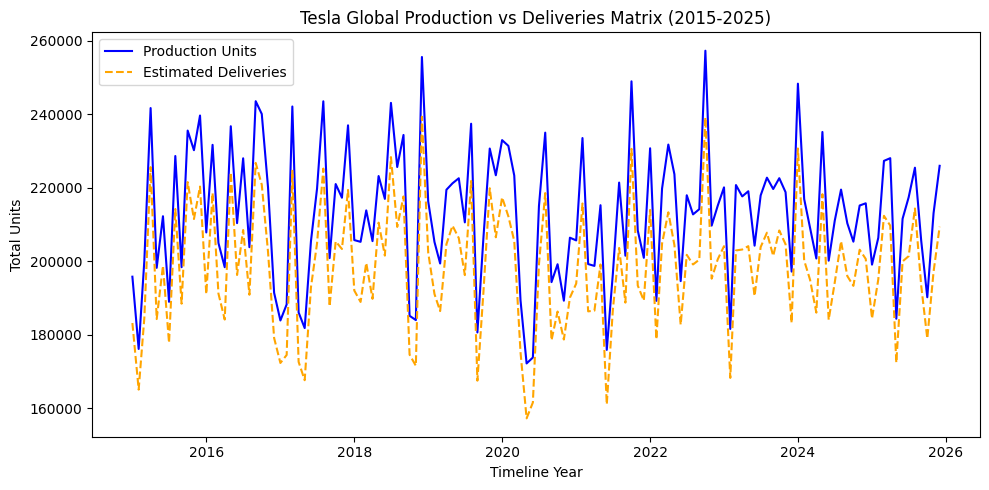

In [2]:
monthly_totals = df.groupby('Date')[['Production_Units', 'Estimated_Deliveries']].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_totals.index, monthly_totals['Production_Units'], label='Production Units', color='blue')
plt.plot(monthly_totals.index, monthly_totals['Estimated_Deliveries'], label='Estimated Deliveries', color='orange', linestyle='--')
plt.title("Tesla Global Production vs Deliveries Matrix (2015-2025)")
plt.xlabel("Timeline Year")
plt.ylabel("Total Units")
plt.legend()
plt.tight_layout()
plt.show() # Displays right inside your notebook

In [3]:
df['Prod_Lag_1M'] = df.groupby(['Region', 'Model'])['Production_Units'].shift(1)
df['Prod_Lag_2M'] = df.groupby(['Region', 'Model'])['Production_Units'].shift(2)
df['Deliveries_RollMean_3M'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1).transform(lambda x: x.rolling(3).mean())

# Drop rows with NaN values created by shifting
df_ml = df.dropna().reset_index(drop=True)
print(f"Features built. Shape after dropping boundary NaNs: {df_ml.shape}")

Features built. Shape after dropping boundary NaNs: (2600, 16)


In [4]:
cat_cols = ['Region', 'Model']
num_cols = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 
            'CO2_Saved_tons', 'Prod_Lag_1M', 'Prod_Lag_2M', 'Deliveries_RollMean_3M']

X = df_ml[cat_cols + num_cols]
y = df_ml['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

transformer = ColumnTransformer([
    ('num_scaler', StandardScaler(), num_cols),
    ('cat_encoder', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

model_pipeline = Pipeline([
    ('preprocessing', transformer),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 8]
}

grid = GridSearchCV(model_pipeline, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
preds = best_model.predict(X_test)

print("--- RandomForest Regressor Pipeline Evaluation ---")
print(f"Optimized Hyperparameters: {grid.best_params_}")
print(f"Test Evaluation RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.2f}")
print(f"Test Evaluation MAE:  {mean_absolute_error(y_test, preds):.2f}")
print(f"Test Evaluation R2:   {r2_score(y_test, preds):.4f}\n")

--- RandomForest Regressor Pipeline Evaluation ---
Optimized Hyperparameters: {'regressor__max_depth': 8, 'regressor__n_estimators': 100}
Test Evaluation RMSE: 409.24
Test Evaluation MAE:  333.13
Test Evaluation R2:   0.9876



In [5]:
ts_data = df_ml.groupby('Date')['Estimated_Deliveries'].sum().asfreq('MS')

ts_model = SARIMAX(ts_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False)
results = ts_model.fit(disp=False)

forecast_steps = 6
forecast_output = results.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=ts_data.index[-1] + pd.offsets.MonthBegin(), periods=forecast_steps, freq='MS')

forecast_df = pd.DataFrame({
    'Projected_Deliveries': forecast_output.predicted_mean.values,
    'Lower_Confidence_Bound': forecast_output.conf_int().iloc[:, 0].values,
    'Upper_Confidence_Bound': forecast_output.conf_int().iloc[:, 1].values
}, index=forecast_index)

print("--- SARIMAX Time Series Forecasting ---")
print(forecast_df.round(1))

--- SARIMAX Time Series Forecasting ---
            Projected_Deliveries  Lower_Confidence_Bound  \
2026-01-01              203974.4                153334.7   
2026-02-01              193101.6                140689.4   
2026-03-01              204071.8                150389.7   
2026-04-01              199839.2                144937.3   
2026-05-01              192386.3                136292.3   
2026-06-01              191685.6                134424.2   

            Upper_Confidence_Bound  
2026-01-01                254614.0  
2026-02-01                245513.9  
2026-03-01                257753.8  
2026-04-01                254741.0  
2026-05-01                248480.4  
2026-06-01                248947.1  
